---
title: "Grouped and temporal data: TabPFN 3 vs 3.5 vs XGBoost"
description: "Compare three models on unseen mice and future fraudulent transactions with leakage-aware evaluation splits."
cookbookTags:
  - classification
  - grouped data
  - time-series
authors:
  - name: Eliott Kalfon
    linkedin: https://www.linkedin.com/in/eliott-kalfon/
---

Can protein measurements identify an unseen mouse’s experimental class, and can
transaction characteristics identify fraud in a future month? Observations from
the same subject or nearby times can make random row splits overly optimistic.
This recipe compares **TabPFN 3, TabPFN 3.5, and XGBoost** in two settings:

| Example | Prediction | Evaluation |
| --- | --- | --- |
| Mice protein expression | Eight experimental classes from protein measurements | Hold out entire mice |
| IEEE-CIS fraud detection | Whether a transaction is labeled fraudulent | Train on earlier months, leave a one-month gap, predict the next month |

Both examples use three published Beyond Arena splits. All models see the same
training and test rows. Start with standard inference, then compare both
TabPFN versions with high-effort Thinking on the same splits.

## Setup

Install the client and dependencies. TabPFN runs through the API; XGBoost
runs on CPU. Authenticate with your usual TabPFN
client setup before running the comparison.

In [ ]:
%pip install -q --upgrade tabpfn-client pandas numpy scikit-learn xgboost matplotlib pyarrow huggingface-hub

In [2]:
import json
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from huggingface_hub import hf_hub_download
from IPython.display import display
from sklearn.metrics import log_loss, average_precision_score
from sklearn.preprocessing import LabelEncoder
from tabpfn_client import TabPFNClassifier
from tabpfn_client.api_models import ModelVersion
from xgboost import XGBClassifier

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False,
                     "axes.spines.right": False})

## Load the curated datasets and their splits

The [Beyond Arena collection](https://huggingface.co/datasets/TabArena/BeyondArena)
includes the data and explicit train/test row indices. Pinning the collection
revision makes these splits reproducible.

The mice task is `1273313252` (`mice_protein_trisomy_discriminant`), derived from
[UCI Mice Protein Expression](https://doi.org/10.24432/C50S3Z), licensed CC BY 4.0.
The curation removes the three columns that directly define the target and
reduces `MouseID` to the actual animal identifier.

The temporal example is `ieee_fraud_detection`, from the
[IEEE-CIS Fraud Detection competition](https://www.kaggle.com/competitions/ieee-fraud-detection/overview).
Beyond Arena joins transaction and identity features, normalizes event-delay
features, and derives `Transaction_date` from the transaction time. Its metadata
permits non-commercial use, including academic research.

The target is `isFraud`: 1 denotes fraud. About 3.5% of the 590,540 transactions
are positive. Labels reflect reported chargebacks and subsequent transactions
linked to known fraudulent accounts, so they are not independent adjudications
of every transaction. We retain the curated features except the row identifier
`TransactionID`. The timestamp guides splitting and Thinking validation.
The split measures future transactions, which can include returning customers;
it does not measure generalization to entirely unseen accounts.

In [3]:
def load_task(name, version, sample_rows=None):
    def download(filename):
        return hf_hub_download(
            "TabArena/BeyondArena", f"{name}/{version}/{filename}",
            repo_type="dataset", revision="88059a3f02ec4abb6ec24bbe0d1c0b7eed31485d",
        )
    frame = pd.read_parquet(download("dataset.parquet"))
    splits = json.loads(Path(download(
        "experiment_metadata.predictive-ml-splits-mold-v1.json"
    )).read_text())["splits"]
    if sample_rows is not None:
        selected = np.sort(np.random.default_rng(42).choice(
            len(frame), size=min(sample_rows, len(frame)), replace=False
        ))
        positions = pd.Series(np.arange(len(selected)), index=selected)
        for folds in splits.values():
            for fold, split in folds.items():
                folds[fold] = [positions.reindex(rows).dropna().astype(int).tolist()
                               for rows in split]
        frame = frame.iloc[selected].reset_index(drop=True)
    return frame, splits

mice, mice_splits = load_task(
    "mice_protein_trisomy_discriminant", "019d738d-99a8-7850-b911-f244ac4ad485"
)
fraud, fraud_splits = load_task(
    "ieee_fraud_detection", "019db516-2f8e-7e50-a8c4-f1c57754f52c", sample_rows=100_000
)
fraud = fraud.drop(columns=["TransactionID"])
print(f"Mice: {len(mice):,} measurements from {mice.MouseID.nunique()} animals")
print(f"IEEE fraud: {len(fraud):,} transactions; {fraud.isFraud.mean():.2%} labeled fraud")

Mice: 1,080 measurements from 72 animals
IEEE fraud: 100,000 transactions; 3.53% labeled fraud


## Check that the split matches deployment

For mice, use the three folds of the first grouped repetition. An animal's
measurements must all stay on one side of the split. For IEEE, retain the three
published temporal splits and their original identifiers: split 0 tests May 2018,
split 1 April, and split 2 March. Each leaves a full month between training and
testing, matching the collection's planning gap.

We load a reproducible sample of 100,000 transactions, preserving their original
split assignments to keep the example manageable. The assertions below check group
separation, strict chronological order, and row disjointness before fitting.
We preserve the planning gap in the outer evaluation; `time_col` alone does not
specify a one-month gap for Thinking's internal validation.

In [4]:
splits = {
    "Mice proteins": [mice_splits["0"][str(fold)] for fold in range(3)],
    "IEEE fraud": [fraud_splits[str(fold)]["0"] for fold in range(3)],
}
split_rows = []
for fold, (train, test) in enumerate(splits["Mice proteins"]):
    assert not set(train) & set(test)
    assert not set(mice.iloc[train].MouseID) & set(mice.iloc[test].MouseID)
    split_rows.append({"Dataset": "Mice proteins", "Split": fold,
                       "Train rows": len(train), "Test rows": len(test),
                       "Train groups": mice.iloc[train].MouseID.nunique(),
                       "Test groups": mice.iloc[test].MouseID.nunique()})
for fold, (train, test) in enumerate(splits["IEEE fraud"]):
    assert not set(train) & set(test)
    end = fraud.iloc[train].Transaction_date.max()
    start = fraud.iloc[test].Transaction_date.min()
    assert end < start
    assert start.to_period("M").ordinal - end.to_period("M").ordinal == 2
    assert set(fraud.iloc[train].isFraud.unique()) == {0, 1}
    split_rows.append({"Dataset": "IEEE fraud", "Split": fold,
                       "Train rows": len(train), "Test rows": len(test),
                       "Train through": end, "Test from": start,
                       "Test through": fraud.iloc[test].Transaction_date.max(),
                       "Test fraud prevalence": fraud.iloc[test].isFraud.mean()})
split_summary = pd.DataFrame(split_rows)
display(split_summary.fillna(""))

,Dataset,Split,Train rows,Test rows,Train groups,Test groups,Train through,Test from,Test through,Test fraud prevalence
0,Mice proteins,0,720,360,48.0,24.0,NaT,NaT,NaT,
1,Mice proteins,1,720,360,48.0,24.0,NaT,NaT,NaT,
2,Mice proteins,2,720,360,48.0,24.0,NaT,NaT,NaT,
3,IEEE fraud,0,70746,15071,,,2018-03-31 23:59:08,2018-05-01 00:04:57,2018-05-31 23:57:29,0.034304
4,IEEE fraud,1,53436,14183,,,2018-02-28 23:59:27,2018-04-01 00:00:50,2018-04-30 23:59:19,0.035818
5,IEEE fraud,2,38965,17310,,,2018-01-31 23:57:43,2018-03-01 00:00:23,2018-03-31 23:59:08,0.039688


### The temporal evaluation at a glance

The upper panel shows the observed weekly fraud rate. The lower panel shows
the training history, one-month gap, and held-out month for each split.
These rates are retrospective context, not predictors. The three test months
remain separate evaluation windows; later training sets can include an earlier
test month as labels become available.

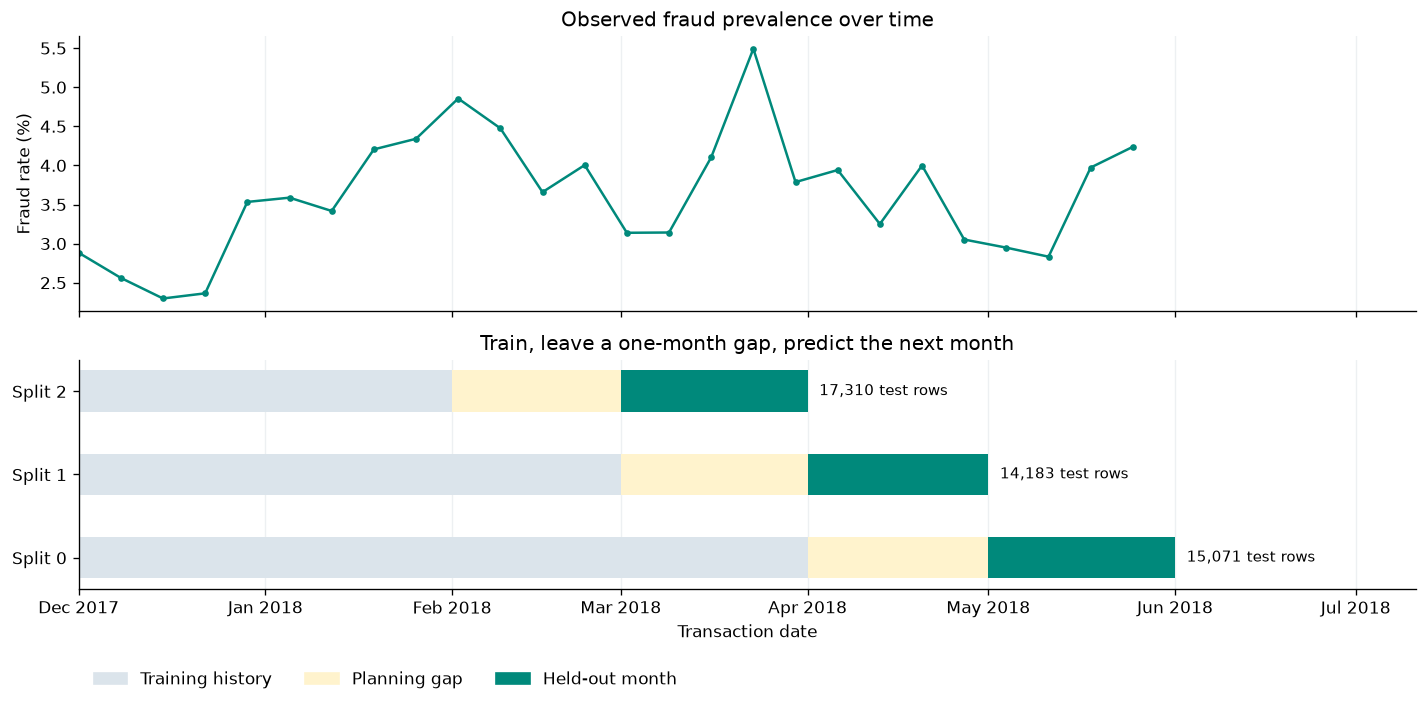

In [5]:
import matplotlib.dates as mdates
from matplotlib.patches import Patch

weekly = fraud.set_index("Transaction_date").isFraud.resample("7D").mean()
fig, (ax_rate, ax_split) = plt.subplots(
    2, 1, figsize=(12, 6), sharex=True, gridspec_kw={"height_ratios": [1.2, 1]}
)
ax_rate.plot(weekly.index, 100 * weekly, color="#00897b", marker="o", markersize=3)
ax_rate.set(ylabel="Fraud rate (%)", title="Observed fraud prevalence over time")
for position, fold in enumerate([2, 1, 0]):
    train, test = splits["IEEE fraud"][fold]
    train_start, train_end = fraud.iloc[train].Transaction_date.agg(["min", "max"])
    test_start, test_end = fraud.iloc[test].Transaction_date.agg(["min", "max"])
    for start, end, color in [(train_start, train_end, "#dbe4eb"),
                              (train_end, test_start, "#fff3cd"),
                              (test_start, test_end, "#00897b")]:
        ax_split.barh(position, mdates.date2num(end) - mdates.date2num(start),
                      left=mdates.date2num(start), height=0.5, color=color)
    ax_split.annotate(f"{len(test):,} test rows", (mdates.date2num(test_end), position),
                      xytext=(7, 0), textcoords="offset points", va="center", fontsize=9)
ax_split.set(yticks=[0, 1, 2], yticklabels=["Split 2", "Split 1", "Split 0"],
             xlabel="Transaction date", title="Train, leave a one-month gap, predict the next month")
ax_split.invert_yaxis()
ax_split.xaxis.set_major_locator(mdates.MonthLocator())
ax_split.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax_split.set_xlim(fraud.Transaction_date.min(), fraud.Transaction_date.max() + pd.Timedelta(days=40))
ax_split.legend(handles=[Patch(color="#dbe4eb", label="Training history"),
                         Patch(color="#fff3cd", label="Planning gap"),
                         Patch(color="#00897b", label="Held-out month")],
                 loc="lower left", frameon=False, ncol=3, bbox_to_anchor=(0, -0.5))
for ax in (ax_rate, ax_split):
    ax.set_axisbelow(True)
    ax.grid(axis="x", color="#edf0f2")
fig.tight_layout()
plt.show()

## Compare the three models

Use protein measurements as predictors and omit `MouseID`. For fraud, omit
`Transaction_date` from standard models. Thinking receives the original group
or time column below to guide validation. Preserve missing values and encode
categorical columns with levels learned from the training rows; unseen test
categories become missing for every model.

Both TabPFN versions keep their default estimator count and random state.
XGBoost uses a fixed CPU histogram configuration: 500 trees, depth 4, and a
learning rate of 0.05. There is no test-set tuning or class resampling.

Use multiclass log-loss for mice (lower is better) and **average precision** for
fraud (higher is better), matching the selected Thinking objectives. Average
precision summarizes precision as recall increases, emphasizing the positive
fraud class. Read it alongside the test month's fraud prevalence; it does not
choose an operational alert threshold or quantify financial losses.
Beyond Arena's task metadata lists ROC-AUC; this cookbook intentionally uses
average precision for the rare-fraud question. This is a fresh comparison with
simple preprocessing, not a reproduction of the collection's tuned baselines.

In [6]:
def prepare(frame, target, split_column, train, test):
    X_train = frame.iloc[train].drop(columns=[target, split_column]).copy()
    X_test = frame.iloc[test].drop(columns=[target, split_column]).copy()
    for column in X_train.select_dtypes(include=["category", "object", "string"]):
        categories = pd.Index(X_train[column].dropna().unique())
        X_train[column] = pd.Categorical(X_train[column], categories=categories)
        X_test[column] = pd.Categorical(X_test[column], categories=categories)
    encoder = LabelEncoder().fit(frame.iloc[train][target])
    return (X_train, X_test, encoder.transform(frame.iloc[train][target]),
            encoder.transform(frame.iloc[test][target]))

def compare(frame, target, split_column, task_splits, name, *,
            metric="Log-loss", thinking_effort=None, thinking_metric=None, group_col=None, time_col=None):
    rows, predictions = [], {}
    for fold, (train, test) in enumerate(task_splits):
        X_train, X_test, y_train, y_test = prepare(frame, target, split_column, train, test)
        categorical = [X_train.columns.get_loc(c) for c in X_train.select_dtypes("category")]
        if thinking_effort is not None:
            # Preserve the original identifiers/order values in both frames for Thinking.
            for column in [group_col, time_col]:
                if column is not None:
                    X_train[column] = frame.iloc[train][column]
                    X_test[column] = frame.iloc[test][column]
        for model_name, version in [("TabPFN 3", ModelVersion.V3),
                                    ("TabPFN 3.5", ModelVersion.V3_5),
                                    ("XGBoost", None)]:
            if thinking_effort is not None and version is None:
                continue
            thinking = {}
            if thinking_effort is not None:
                model_name += " Thinking (high)"
                thinking = dict(thinking_effort=thinking_effort, thinking_metric=thinking_metric,
                                group_col=group_col, time_col=time_col)
            model = (XGBClassifier(
                n_estimators=500, max_depth=4, learning_rate=0.05,
                tree_method="hist", device="cpu", enable_categorical=True,
                n_jobs=8, random_state=42,
            ) if version is None else TabPFNClassifier.create_default_for_version(
                version,
                categorical_features_indices=categorical, **thinking,
            ))
            started = time.perf_counter()
            model.fit(X_train, y_train)
            prediction = model.predict_proba(X_test)
            seconds = time.perf_counter() - started
            assert np.isfinite(prediction).all()
            assert np.allclose(prediction.sum(axis=1), 1, atol=1e-5)
            assert np.array_equal(model.classes_, np.arange(len(np.unique(y_train))))
            rows.append({"Dataset": name, "Split": fold, "Model": model_name,
                         "Log-loss": log_loss(y_test, prediction) if metric == "Log-loss" else np.nan,
                         "Average precision": average_precision_score(y_test, prediction[:, 1]) if metric == "Average precision" else np.nan,
                         "Seconds": seconds})
            predictions[f"{fold}_{model_name}"] = prediction
            predictions[f"{fold}_y_test"] = y_test
            print(f"{name}, split {fold}: {model_name} finished in {seconds:.1f}s", flush=True)
    return pd.DataFrame(rows), predictions

### Unseen mice

Each test fold contains 24 animals, with 15 measurements per animal. Log-loss
is averaged over measurements; because each animal has the same number of
measurements, each animal has equal weight. The three folds are the evaluation
units, not 1,080 independent animals.

In [7]:
mice_results, mice_predictions = compare(
    mice, "class", "MouseID", splits["Mice proteins"], "Mice proteins"
)
display(mice_results[["Dataset", "Split", "Model", "Log-loss"]].round(4))

Mice proteins, split 0: restored TabPFN 3


Mice proteins, split 0: restored TabPFN 3.5


Mice proteins, split 0: restored XGBoost


Mice proteins, split 1: restored TabPFN 3


Mice proteins, split 1: restored TabPFN 3.5


Mice proteins, split 1: restored XGBoost


Mice proteins, split 2: restored TabPFN 3


Mice proteins, split 2: restored TabPFN 3.5


Mice proteins, split 2: restored XGBoost


,Dataset,Split,Model,Log-loss
0,Mice proteins,0,TabPFN 3,1.0772
1,Mice proteins,0,TabPFN 3.5,0.7729
2,Mice proteins,0,XGBoost,1.7709
3,Mice proteins,1,TabPFN 3,1.1772
4,Mice proteins,1,TabPFN 3.5,0.6991
5,Mice proteins,1,XGBoost,2.3423
6,Mice proteins,2,TabPFN 3,1.1296
7,Mice proteins,2,TabPFN 3.5,0.7970
8,Mice proteins,2,XGBoost,1.6562


### Future fraudulent transactions

Fit on earlier transactions, leave the prescribed month-long gap, and predict
the held-out month. Each model uses identical rows and predictors.

In [8]:
fraud_results, fraud_predictions = compare(
    fraud, "isFraud", "Transaction_date", splits["IEEE fraud"], "IEEE fraud",
    metric="Average precision",
)
display(fraud_results[["Dataset", "Split", "Model", "Average precision"]].round(4))

IEEE fraud, split 0: restored TabPFN 3


IEEE fraud, split 0: restored TabPFN 3.5


IEEE fraud, split 0: restored XGBoost


IEEE fraud, split 1: restored TabPFN 3


IEEE fraud, split 1: restored TabPFN 3.5


IEEE fraud, split 1: restored XGBoost


IEEE fraud, split 2: restored TabPFN 3


IEEE fraud, split 2: restored TabPFN 3.5


IEEE fraud, split 2: restored XGBoost


,Dataset,Split,Model,Average precision
0,IEEE fraud,0,TabPFN 3,0.4826
1,IEEE fraud,0,TabPFN 3.5,0.5718
2,IEEE fraud,0,XGBoost,0.4618
3,IEEE fraud,1,TabPFN 3,0.4478
4,IEEE fraud,1,TabPFN 3.5,0.5369
5,IEEE fraud,1,XGBoost,0.4347
6,IEEE fraud,2,TabPFN 3,0.5031
7,IEEE fraud,2,TabPFN 3.5,0.5490
8,IEEE fraud,2,XGBoost,0.4800


## Performance on grouped and temporal data

Bars show the mean across three splits. Dots show individual scores, making
variation across mice folds and test months visible. Lower log-loss is better;
higher average precision is better. When scores are close, the chart uses a
clearly labeled zoomed axis. Dots are descriptive, not confidence intervals.

Mice proteins: Log-loss


,Log-loss
Model,
TabPFN 3,1.1280
TabPFN 3.5,0.7563
XGBoost,1.9231


IEEE fraud: Average precision


,Average precision
Model,
TabPFN 3,0.4779
TabPFN 3.5,0.5526
XGBoost,0.4588


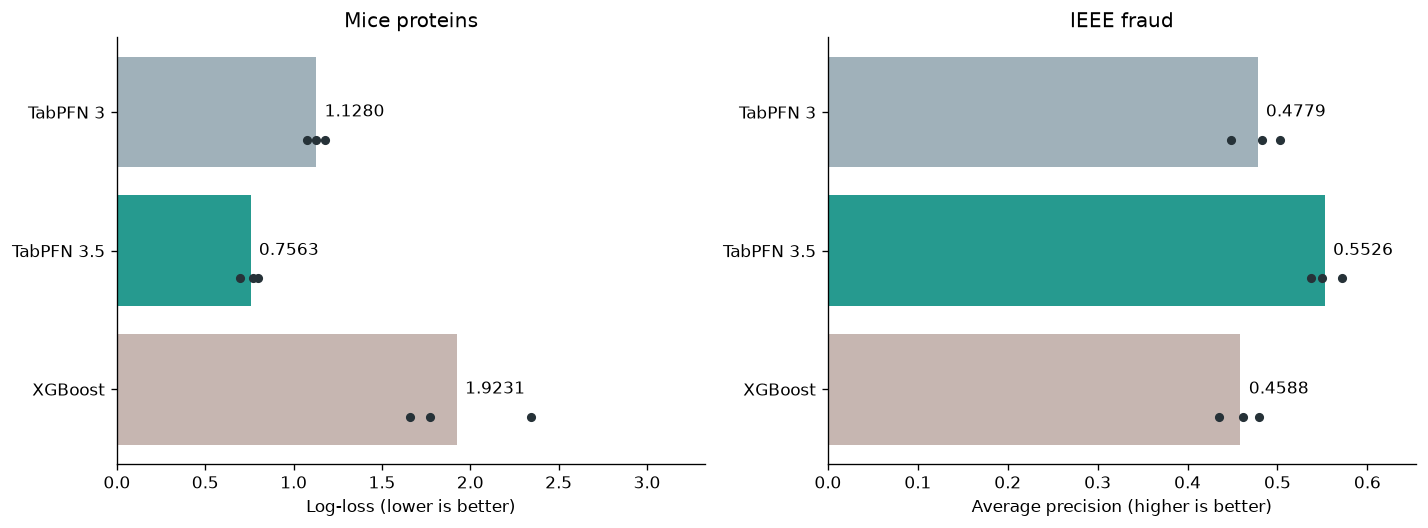

In [9]:
all_results = pd.concat([mice_results, fraud_results], ignore_index=True)
summary = all_results.groupby(["Dataset", "Model"], sort=False)[
    ["Log-loss", "Average precision", "Seconds"]
].mean()
for dataset, metric in [("Mice proteins", "Log-loss"), ("IEEE fraud", "Average precision")]:
    print(f"{dataset}: {metric}")
    display(summary.loc[dataset, [metric]].round(4))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, (dataset, metric, direction) in zip(axes, [
    ("Mice proteins", "Log-loss", "lower"),
    ("IEEE fraud", "Average precision", "higher"),
]):
    scores = all_results[all_results.Dataset == dataset].pivot(
        index="Model", columns="Split", values=metric
    ).reindex(["TabPFN 3", "TabPFN 3.5", "XGBoost"])
    bars = ax.barh(scores.index, scores.mean(axis=1),
                   color=["#90a4ae", "#00897b", "#bcaaa4"], alpha=0.85)
    ax.bar_label(bars, fmt="%.4f", padding=5)
    for position, (_, values) in enumerate(scores.iterrows()):
        ax.scatter(values, np.full(3, position + 0.20), color="#263238", s=20, zorder=3)
    low, high = scores.to_numpy().min(), scores.to_numpy().max()
    zoomed = low > 0 and high - low < 0.2 * high
    padding = max((high - low) * 0.3, high * 0.015, 0.001)
    ax.set_xlim(max(0, low - padding) if zoomed else 0, high + 2 * padding)
    ax.set_title(dataset + ("\nZoomed axis (does not start at zero)" if zoomed else ""))
    ax.set_xlabel(f"{metric} ({direction} is better)")
    ax.invert_yaxis()
fig.tight_layout()
plt.show()

## Try high-effort Thinking

[Thinking mode](https://github.com/PriorLabs/tabpfn-client#thinking-mode) spends
more computation during `fit()` searching model configurations. Set
`thinking_effort="high"` and choose the objective before fitting: `log_loss`
for mice and `average_precision` for fraud. Both tasks use `predict_proba()`.

Run the same splits with the same training rows and preprocessing. Only
training labels are passed to `fit()`; held-out labels are used for scoring.
Pass `group_col="MouseID"` for mice to keep animals together in internal
validation, and `time_col="Transaction_date"` for fraud to use contiguous
time blocks. Preserve those original columns in both training and test frames
for Thinking. Standard models omit them. The outer evaluation retains the
published month-long planning gap independently of Thinking's validation.

In [10]:
mice_thinking, mice_thinking_predictions = compare(
    mice, "class", "MouseID", splits["Mice proteins"], "Mice proteins",
    thinking_effort="high", thinking_metric="log_loss", group_col="MouseID",
)
fraud_thinking, fraud_thinking_predictions = compare(
    fraud, "isFraud", "Transaction_date", splits["IEEE fraud"], "IEEE fraud",
    metric="Average precision", thinking_effort="high",
    thinking_metric="average_precision", time_col="Transaction_date",
)

Mice proteins, split 0: restored TabPFN 3 Thinking (high)


Mice proteins, split 0: restored TabPFN 3.5 Thinking (high)


Mice proteins, split 1: restored TabPFN 3 Thinking (high)


Mice proteins, split 1: restored TabPFN 3.5 Thinking (high)


Mice proteins, split 2: restored TabPFN 3 Thinking (high)


...

IEEE fraud, split 0: restored TabPFN 3.5 Thinking (high)


IEEE fraud, split 1: restored TabPFN 3 Thinking (high)


IEEE fraud, split 1: restored TabPFN 3.5 Thinking (high)


IEEE fraud, split 2: restored TabPFN 3 Thinking (high)


IEEE fraud, split 2: restored TabPFN 3.5 Thinking (high)


### Does Thinking improve held-out performance?

Compare each version with its standard counterpart using the metric selected
for Thinking. Bars show the three-split mean and dots show individual splits.
Each table shows only that task's selected metric. XGBoost remains the fixed
CPU baseline.

Mice proteins: Log-loss (lower is better)


,Log-loss
Model,
TabPFN 3,1.1280
TabPFN 3 Thinking (high),1.0963
TabPFN 3.5,0.7563
TabPFN 3.5 Thinking (high),0.7339
XGBoost,1.9231


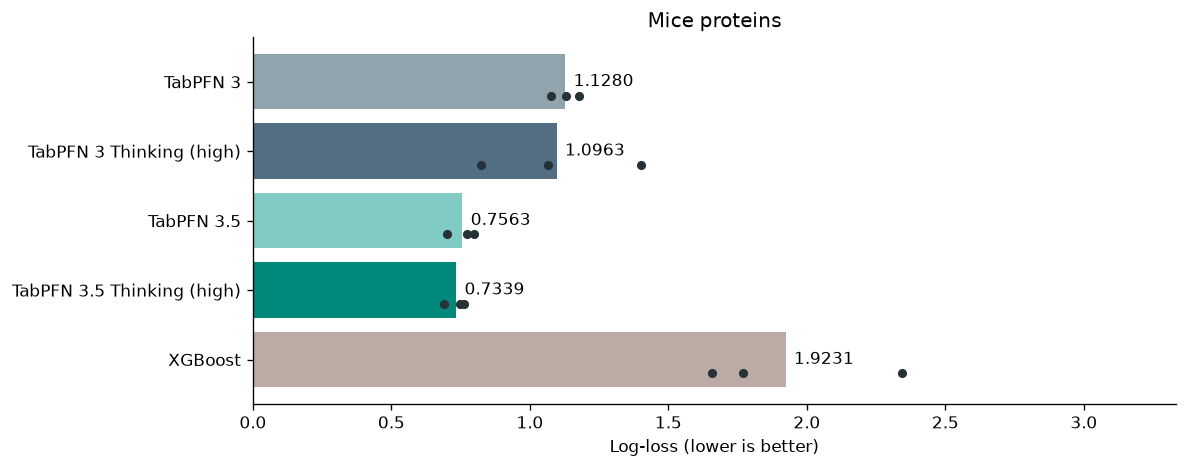

IEEE fraud: Average precision (higher is better)


,Average precision
Model,
TabPFN 3,0.4779
TabPFN 3 Thinking (high),0.5054
TabPFN 3.5,0.5526
TabPFN 3.5 Thinking (high),0.5410
XGBoost,0.4588


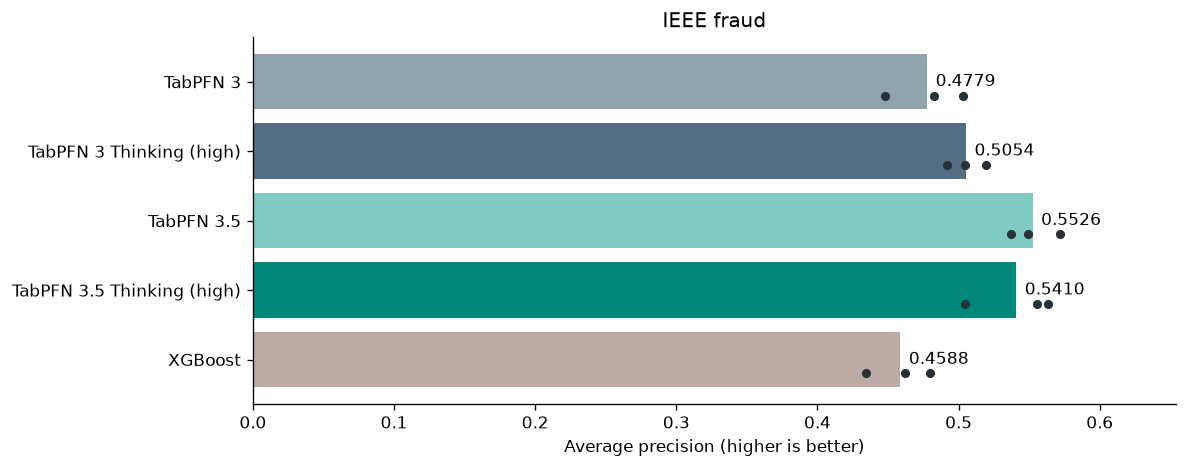

In [11]:
all_results = pd.concat([all_results, mice_thinking, fraud_thinking], ignore_index=True)
summary = all_results.groupby(["Dataset", "Model"], sort=False)[
    ["Log-loss", "Average precision", "Seconds"]
].mean()
model_order = ["TabPFN 3", "TabPFN 3 Thinking (high)",
               "TabPFN 3.5", "TabPFN 3.5 Thinking (high)", "XGBoost"]
for dataset, metric, direction in [
    ("Mice proteins", "Log-loss", "lower"),
    ("IEEE fraud", "Average precision", "higher"),
]:
    print(f"{dataset}: {metric} ({direction} is better)")
    display(summary.loc[dataset, [metric]].reindex(model_order).round(4))
    scores = all_results[all_results.Dataset == dataset].pivot(
        index="Model", columns="Split", values=metric
    ).reindex(model_order)
    fig, ax = plt.subplots(figsize=(10, 4))
    bars = ax.barh(scores.index, scores.mean(axis=1),
                   color=["#90a4ae", "#536d83", "#80cbc4", "#00897b", "#bcaaa4"])
    ax.bar_label(bars, fmt="%.4f", padding=5)
    for position, (_, values) in enumerate(scores.iterrows()):
        ax.scatter(values, np.full(len(values), position + 0.20),
                   color="#263238", s=20, zorder=3)
    low, high = scores.to_numpy().min(), scores.to_numpy().max()
    zoomed = low > 0 and high - low < 0.2 * high
    padding = max((high - low) * 0.3, high * 0.015, 0.001)
    ax.set_xlim(max(0, low - padding) if zoomed else 0, high + 2 * padding)
    ax.set_title(dataset + ("\nZoomed axis (does not start at zero)" if zoomed else ""))
    ax.set_xlabel(f"{metric} ({direction} is better)")
    ax.invert_yaxis()
    fig.tight_layout()
    plt.show()

## Reading the comparison

For Mice proteins, mean log-loss is **1.1280** for TabPFN 3, **0.7563** for TabPFN 3.5, and **1.9231** for XGBoost (lower is better).

TabPFN 3 Thinking improves mean log-loss from **1.1280 to 1.0963**, improving 2 of the three splits.

TabPFN 3.5 Thinking improves mean log-loss from **0.7563 to 0.7339**, improving 3 of the three splits.

For IEEE fraud, mean average precision is **0.4779** for TabPFN 3, **0.5526** for TabPFN 3.5, and **0.4588** for XGBoost (higher is better).

TabPFN 3 Thinking improves mean average precision from **0.4779 to 0.5054**, improving 3 of the three splits.

TabPFN 3.5 Thinking worsens mean average precision from **0.5526 to 0.5410**, improving 1 of the three splits.

Choose a split that matches the next prediction: unseen subjects for grouped
data, future months for fraud detection. Keep the split fixed across models
and inspect individual split scores alongside their mean. Average precision
is evaluated against the positive `isFraud=1` class.

The mice example was selected after inspecting earlier Beyond Arena results;
IEEE fraud was chosen to illustrate temporal fraud detection. These are curated
examples, not an unbiased benchmark of which model wins across all datasets.
Results describe these tasks and the fixed baseline configuration.